<a href="https://colab.research.google.com/github/nithishavittam/-SCT_WD_2-/blob/main/SCT_WD_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


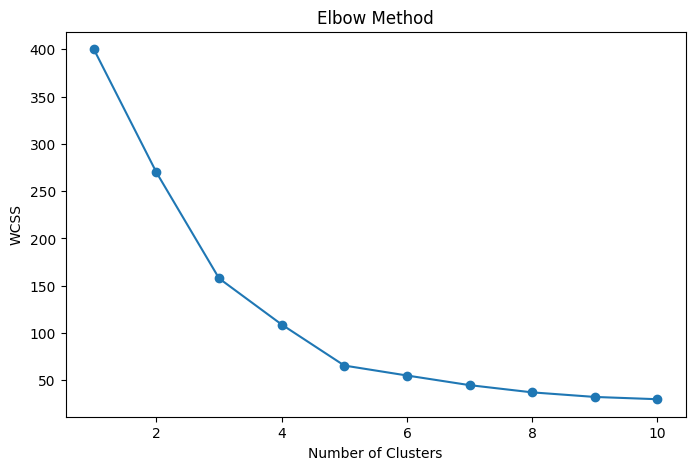

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


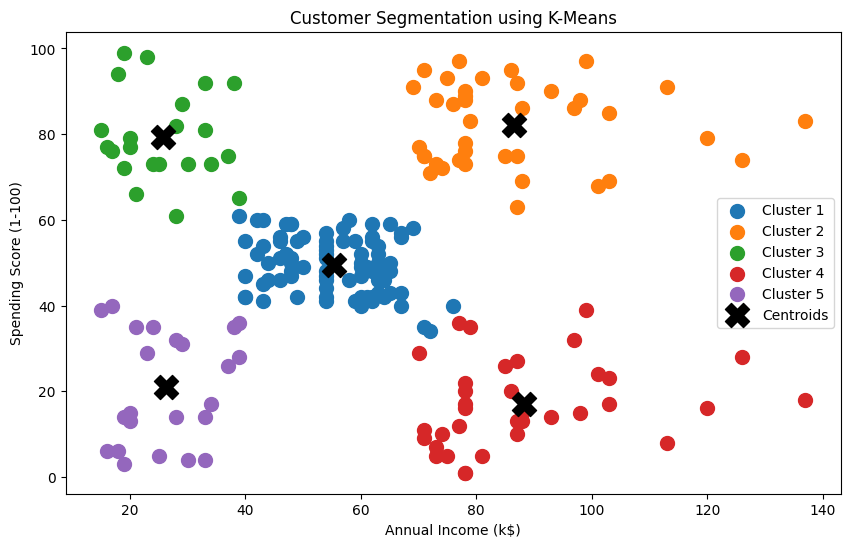

Clustering completed successfully!


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("Mall_Customers (2).csv")

# Display first few rows
print(df.head())

# Select features for clustering
# Annual Income and Spending Score are commonly used
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal number of clusters using Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++',
                    max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Train K-Means with optimal clusters (usually 5)
kmeans = KMeans(n_clusters=5, init='k-means++',
                max_iter=300, n_init=10, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df['Cluster'] = clusters

# Display clustered data
print(df.head())

# Visualize Clusters
plt.figure(figsize=(10, 6))

plt.scatter(
    df[df['Cluster'] == 0]['Annual Income (k$)'],
    df[df['Cluster'] == 0]['Spending Score (1-100)'],
    s=100, label='Cluster 1'
)

plt.scatter(
    df[df['Cluster'] == 1]['Annual Income (k$)'],
    df[df['Cluster'] == 1]['Spending Score (1-100)'],
    s=100, label='Cluster 2'
)

plt.scatter(
    df[df['Cluster'] == 2]['Annual Income (k$)'],
    df[df['Cluster'] == 2]['Spending Score (1-100)'],
    s=100, label='Cluster 3'
)

plt.scatter(
    df[df['Cluster'] == 3]['Annual Income (k$)'],
    df[df['Cluster'] == 3]['Spending Score (1-100)'],
    s=100, label='Cluster 4'
)

plt.scatter(
    df[df['Cluster'] == 4]['Annual Income (k$)'],
    df[df['Cluster'] == 4]['Spending Score (1-100)'],
    s=100, label='Cluster 5'
)

# Plot centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

# Save clustered dataset
df.to_csv("Mall_Customers_Clustered.csv", index=False)

print("Clustering completed successfully!")